### Importing

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Input , Dense , Dropout
from keras.utils import to_categorical
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam , RMSprop , SGD

### Loading Data

In [8]:
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [9]:
print(iris["DESCR"])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Feature & Target Split

In [11]:
X = iris["data"]
y = iris["target"]

print(X.shape)
print(y.shape)

(150, 4)
(150,)


### Train & Test Split

In [15]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 101)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


### Min Max Scaler

In [16]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### One Hot Encoding

In [17]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Adding Layer

In [20]:
model = Sequential()
model.add(Input(shape = (X_train.shape[1] , )))
model.add(Dense(units = 10 , activation = "relu"))
model.add(Dense(units = 10 , activation = "relu"))
model.add(Dropout(rate = 0.3))
model.add(Dense(units = 3 , activation = "softmax"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Compiling Model

In [22]:
model.compile(loss = CategoricalCrossentropy() , optimizer = Adam(learning_rate = 0.01) , metrics = ["accuracy"])

### Training Model

In [24]:
history = model.fit(X_train , y_train , epochs = 100 , validation_data = (X_test , y_test))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8833 - loss: 0.1941 - val_accuracy: 1.0000 - val_loss: 0.0663
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8667 - loss: 0.2232 - val_accuracy: 1.0000 - val_loss: 0.0679
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9000 - loss: 0.1695 - val_accuracy: 0.9667 - val_loss: 0.0651
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9000 - loss: 0.1915 - val_accuracy: 0.9667 - val_loss: 0.0645
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8583 - loss: 0.2614 - val_accuracy: 1.0000 - val_loss: 0.0689
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9250 - loss: 0.1546 - val_accuracy: 0.9667 - val_loss: 0.0651
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9250 - loss: 0.1736 - val_accuracy: 0.9667 - val_loss: 0.0690
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9250 - loss: 0.1669 - val_accuracy: 0.9667 - val_loss:

### History Visualization

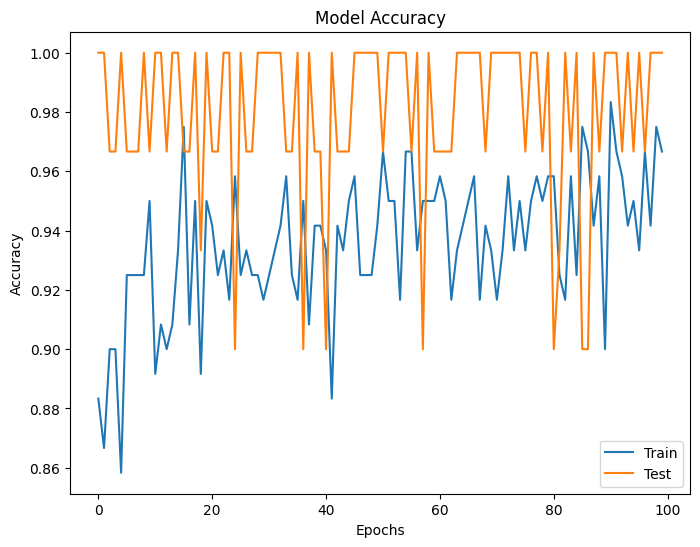

In [25]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train" , "Test"])
plt.show()

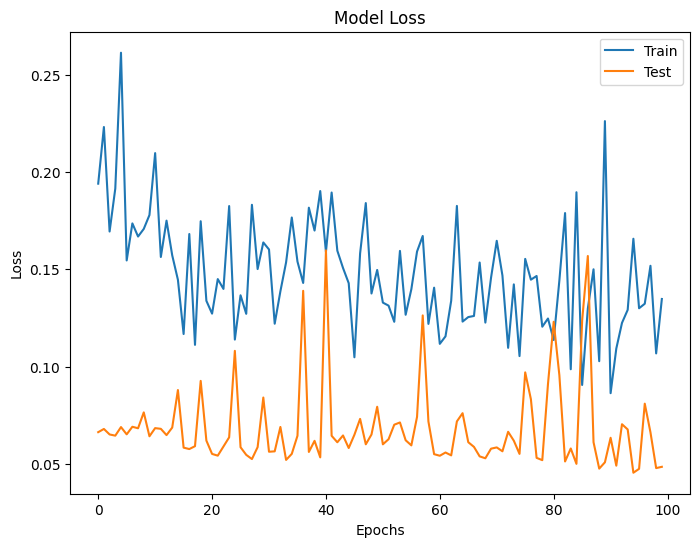

In [26]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train" , "Test"])
plt.show()

### Evaluation

In [27]:
result = model.evaluate(X_test , y_test , verbose = 0)
print(f"Accuracy : {result[1]} , Loss : {result[0]}")

Accuracy : 1.0 , Loss : 0.048434533178806305


In [31]:
print(classification_report(y_test.argmax(axis = 1) , model.predict(X_test).argmax(axis = 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


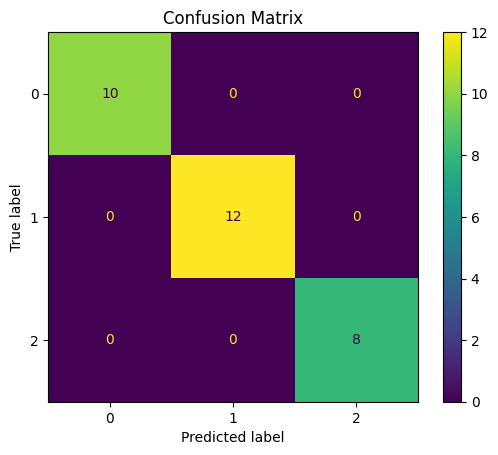

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test.argmax(axis = 1) , model.predict(X_test).argmax(axis = 1))
plt.title("Confusion Matrix")
plt.show()